In [1]:
!python -V

Python 3.13.0


In [2]:
import pandas as pd
import numpy as np
import pickle


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope


C:\Users\PrashantKumar6\AppData\Roaming\Python\Python313\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [5]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("nyc-taxi-experiment")

<Experiment: artifact_location='/workspaces/mlops-zoomcamp/03-training/experiment_tracking/mlruns/1', creation_time=1776073108123, experiment_id='1', last_update_time=1776355450636, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}, trace_location=None, workspace='default'>

In [6]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

from sklearn.metrics import root_mean_squared_error

PULocationID    int64
DOLocationID    int64
dtype: object

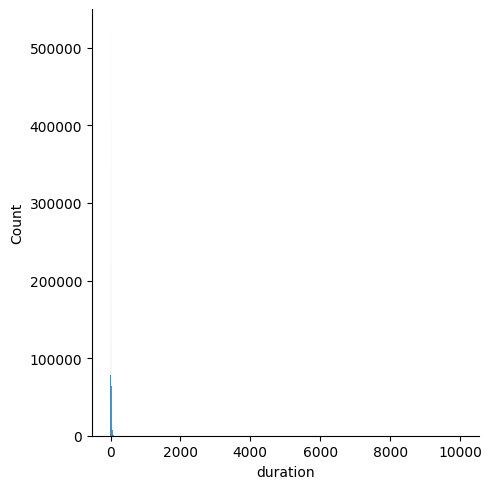

In [7]:
df = pd.read_parquet('data/yellow_tripdata_2023-01.parquet')

df.tpep_dropoff_datetime = pd.to_datetime(df.tpep_dropoff_datetime )
df.tpep_pickup_datetime = pd.to_datetime(df.tpep_pickup_datetime)

df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60 )
td = df.duration.iloc[0]
# Removed trip_type filter for yellow taxi data
sns.displot(df.duration)

df.duration.describe(percentiles=[0.95, 0.98, 0.99])
#df = df[((df.duration >= 1) & (df.duration <= 60))]
df = df = df[((df.duration >= 1) & (df.duration <= 60))]
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']
df[categorical].dtypes

In [8]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,duration
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.30,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00,8.433333
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.90,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00,6.316667
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.90,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00,12.750000
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.10,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25,9.616667
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.40,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00,10.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3066761,2,2023-01-31 23:58:34,2023-02-01 00:12:33,NaN,3.05,NaN,None,107,48,0,15.80,0.00,0.5,3.96,0.0,1.0,23.76,NaN,NaN,13.983333
3066762,2,2023-01-31 23:31:09,2023-01-31 23:50:36,NaN,5.80,NaN,None,112,75,0,22.43,0.00,0.5,2.64,0.0,1.0,29.07,NaN,NaN,19.450000
3066763,2,2023-01-31 23:01:05,2023-01-31 23:25:36,NaN,4.67,NaN,None,114,239,0,17.61,0.00,0.5,5.32,0.0,1.0,26.93,NaN,NaN,24.516667
3066764,2,2023-01-31 23:40:00,2023-01-31 23:53:00,NaN,3.15,NaN,None,230,79,0,18.15,0.00,0.5,4.43,0.0,1.0,26.58,NaN,NaN,13.000000


In [9]:
#td.total_seconds()

In [10]:
df.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
duration                        float64
dtype: object

In [11]:
df[categorical] = df[categorical].astype(str)

In [12]:
df[categorical + numerical].iloc[:10].to_dict(orient='records')

[{'PULocationID': '161', 'DOLocationID': '141', 'trip_distance': 0.97},
 {'PULocationID': '43', 'DOLocationID': '237', 'trip_distance': 1.1},
 {'PULocationID': '48', 'DOLocationID': '238', 'trip_distance': 2.51},
 {'PULocationID': '138', 'DOLocationID': '7', 'trip_distance': 1.9},
 {'PULocationID': '107', 'DOLocationID': '79', 'trip_distance': 1.43},
 {'PULocationID': '161', 'DOLocationID': '137', 'trip_distance': 1.84},
 {'PULocationID': '239', 'DOLocationID': '143', 'trip_distance': 1.66},
 {'PULocationID': '142', 'DOLocationID': '200', 'trip_distance': 11.7},
 {'PULocationID': '164', 'DOLocationID': '236', 'trip_distance': 2.95},
 {'PULocationID': '141', 'DOLocationID': '107', 'trip_distance': 3.01}]

In [13]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

In [14]:
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

In [15]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9027519 stored elements and shape (3009173, 516)>

In [16]:
dv.feature_names_

['DOLocationID=1',
 'DOLocationID=10',
 'DOLocationID=100',
 'DOLocationID=101',
 'DOLocationID=102',
 'DOLocationID=106',
 'DOLocationID=107',
 'DOLocationID=108',
 'DOLocationID=109',
 'DOLocationID=11',
 'DOLocationID=111',
 'DOLocationID=112',
 'DOLocationID=113',
 'DOLocationID=114',
 'DOLocationID=115',
 'DOLocationID=116',
 'DOLocationID=117',
 'DOLocationID=118',
 'DOLocationID=119',
 'DOLocationID=12',
 'DOLocationID=120',
 'DOLocationID=121',
 'DOLocationID=122',
 'DOLocationID=123',
 'DOLocationID=124',
 'DOLocationID=125',
 'DOLocationID=126',
 'DOLocationID=127',
 'DOLocationID=128',
 'DOLocationID=129',
 'DOLocationID=13',
 'DOLocationID=130',
 'DOLocationID=131',
 'DOLocationID=132',
 'DOLocationID=133',
 'DOLocationID=134',
 'DOLocationID=135',
 'DOLocationID=136',
 'DOLocationID=137',
 'DOLocationID=138',
 'DOLocationID=139',
 'DOLocationID=14',
 'DOLocationID=140',
 'DOLocationID=141',
 'DOLocationID=142',
 'DOLocationID=143',
 'DOLocationID=144',
 'DOLocationID=145',

In [17]:
target = 'duration'
y_train = df[target].values

In [18]:
y_train

array([ 8.43333333,  6.31666667, 12.75      , ..., 24.51666667,
       13.        , 14.4       ], shape=(3009173,))

In [19]:
target = 'duration'
y_train = df[target].values

In [20]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred = lr.predict(X_train)

C:\Users\PrashantKumar6\AppData\Local\Temp\ipykernel_44788\3863800590.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
C:\Users\PrashantKumar6\AppData\Local\Temp\ipykernel_44788\3863800590.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label = 'actual

<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

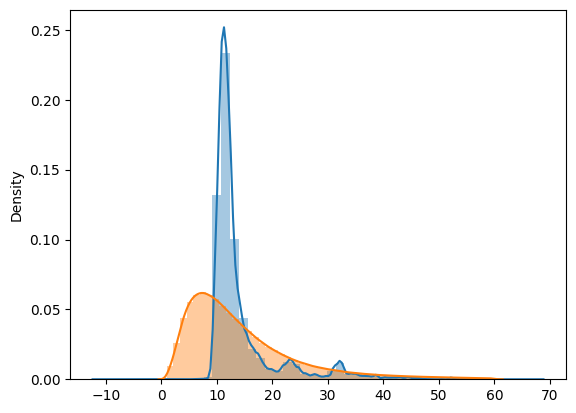

In [22]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label = 'actual')

plt.legend

In [23]:
#mean_squared_error(y_train, y_pred, squared=False)
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

7.6584039350980575

C:\Users\PrashantKumar6\AppData\Local\Temp\ipykernel_44788\1672306066.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
C:\Users\PrashantKumar6\AppData\Local\Temp\ipykernel_44788\1672306066.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')

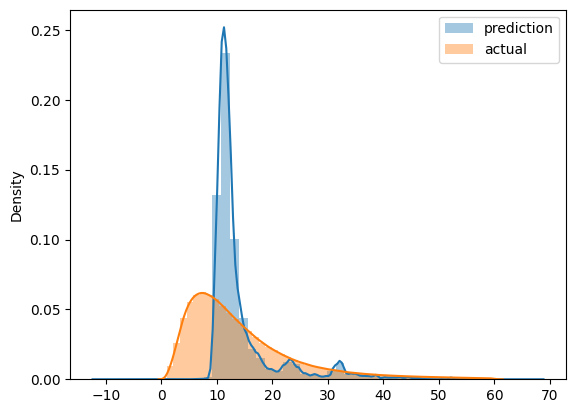

In [24]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()

In [25]:
def read_dataframe(filename):
    df = pd.read_parquet(filename)

    df.tpep_dropoff_datetime = pd.to_datetime(df.tpep_dropoff_datetime )
    df.tpep_pickup_datetime = pd.to_datetime(df.tpep_pickup_datetime)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60 )
    df = df[((df.duration >= 1) & (df.duration <= 60))]
    categorical = ['PULocationID', 'DOLocationID']
    numerical = ['trip_distance']
    df[categorical] = df[categorical].astype(str)

    return df

In [26]:
df_train = read_dataframe('data/yellow_tripdata_2023-01.parquet')
df_val = read_dataframe('data/yellow_tripdata_2023-02.parquet')

In [27]:
print(df_train.shape)
print(df_val.shape)

(3009173, 20)
(2855951, 20)


In [28]:
df_val

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,duration
0,1,2023-02-01 00:32:53,2023-02-01 00:34:34,2.0,0.30,1.0,N,142,163,2,4.40,3.50,0.5,0.00,0.0,1.0,9.40,2.5,0.00,1.683333
3,1,2023-02-01 00:29:33,2023-02-01 01:01:38,0.0,18.80,1.0,N,132,26,1,70.90,2.25,0.5,0.00,0.0,1.0,74.65,0.0,1.25,32.083333
4,2,2023-02-01 00:12:28,2023-02-01 00:25:46,1.0,3.22,1.0,N,161,145,1,17.00,1.00,0.5,3.30,0.0,1.0,25.30,2.5,0.00,13.300000
5,1,2023-02-01 00:52:40,2023-02-01 01:07:18,1.0,5.10,1.0,N,148,236,1,21.90,3.50,0.5,5.35,0.0,1.0,32.25,2.5,0.00,14.633333
6,1,2023-02-01 00:12:39,2023-02-01 00:40:36,1.0,8.90,1.0,N,137,244,1,41.50,3.50,0.5,3.50,0.0,1.0,50.00,2.5,0.00,27.950000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2913950,2,2023-02-28 23:46:00,2023-03-01 00:05:00,NaN,4.65,NaN,None,249,140,0,20.22,0.00,0.5,4.84,0.0,1.0,29.06,NaN,NaN,19.000000
2913951,2,2023-02-28 23:26:02,2023-02-28 23:37:10,NaN,2.47,NaN,None,186,79,0,13.66,0.00,0.5,2.65,0.0,1.0,20.31,NaN,NaN,11.133333
2913952,2,2023-02-28 23:24:00,2023-02-28 23:38:00,NaN,3.49,NaN,None,158,143,0,17.64,0.00,0.5,0.00,0.0,1.0,21.64,NaN,NaN,14.000000
2913953,2,2023-02-28 23:03:00,2023-02-28 23:10:00,NaN,2.13,NaN,None,79,162,0,13.56,0.00,0.5,2.63,0.0,1.0,20.19,NaN,NaN,7.000000


In [29]:
len(df_train), len(df_val)

(3009173, 2855951)

In [30]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [31]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [32]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [33]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

5.247298257697339

In [34]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [35]:
lr = Lasso(0.01)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

9.395699095786842

In [36]:
#mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("nyc-taxi-experiment")
with mlflow.start_run():

    mlflow.set_tag("developer", "Prashant")
    mlflow.log_param("train-data-path", "data/yellow_tripdata_2023-01.parquet")
    mlflow.log_param("valid-data-path", "data/yellow_tripdata_2023-02.parquet")
    alpha = 0.01
    
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)

    #root_mean_squared_error(y_val, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_val, y_pred ))
    mlflow.log_metric("rmse", rmse)

    import os
    os.makedirs("models", exist_ok=True)

    with open("models/lasso_model.bin", "wb") as f_out:
        pickle.dump((dv, lr), f_out)

    mlflow.log_artifact("models/lasso_model.bin", artifact_path="models")

🏃 View run sincere-quail-506 at: http://127.0.0.1:5000/#/experiments/1/runs/52012fe6eda84fd0ae0145cbba5bba58
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [37]:
with mlflow.start_run():
    mlflow.log_metric("test_metric", 100)

🏃 View run stylish-crab-491 at: http://127.0.0.1:5000/#/experiments/1/runs/16df68fc7d334ff79b2bf8863113106d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [38]:
import xgboost as xgb

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope


train = xgb.DMatrix(X_train, label=y_train) 

valid = xgb.DMatrix(X_val, label=y_val)

In [39]:
 # 1. Define 'train' BEFORE the objective function


from sklearn.metrics import root_mean_squared_error



def objective(params):
    with mlflow.start_run():
         mlflow.set_tag("model", "xgboost")

         mlflow.log_params(params)

         booster = xgb.train(

             params=params,

             dtrain=train,

             num_boost_round=1000,

             evals=[(valid, "validation")],

             early_stopping_rounds=50

         )



         y_pred = booster.predict(valid)

         #rmse = mean_squared_error(y_val, y_pred, squared=False)

         rmse = root_mean_squared_error(y_val, y_pred)

         mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}



In [ ]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:squarederror',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

[0]	validation-rmse:7.94322                           
[1]	validation-rmse:6.64116                           
[2]	validation-rmse:5.87768                           
[3]	validation-rmse:5.44539                           
[4]	validation-rmse:5.20273                           
[5]	validation-rmse:5.06603                           
[6]	validation-rmse:4.98633                           
[7]	validation-rmse:4.93692                           
[8]	validation-rmse:4.90446                           
[9]	validation-rmse:4.88325                           
[10]	validation-rmse:4.86809                          
[11]	validation-rmse:4.85595                          
[12]	validation-rmse:4.84753                          
[13]	validation-rmse:4.84143                          
[14]	validation-rmse:4.83543                          
[15]	validation-rmse:4.83068                          
[16]	validation-rmse:4.82836                          
[17]	validation-rmse:4.82616                          
[18]	valid

In [ ]:

params = {
    "learning_rate": 0.11405108312176798,    
    "max_depth": 56,
    "min_child_weight": 0.6198941131788933,
    "objective": "reg:squarederror",
    "reg_alpha": 0.137154656343802,
    "reg_lambda": 0.1555608910736085,
    "seed": 42
}

mlflow.xgboost.autolog()
booster = xgb.train(

params=params,
dtrain=train,
num_boost_round=1000,
evals=[(valid, "validation")],
early_stopping_rounds=50
)

2026/04/19 21:05:18 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '13adc5ed324d4b3aab3df831287bd696', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
C:\Users\PrashantKumar6\AppData\Roaming\Python\Python313\site-packages\xgboost\callback.py:385: UserWarning: [21:05:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[0]	validation-rmse:53.06504
[1]	validation-rmse:53.22338
[2]	validation-rmse:53.57404
[3]	validation-rmse:54.05098
[4]	validation-rmse:54.60823
[5]	validation-rmse:55.21088
[6]	validation-rmse:55.82895
[7]	validation-rmse:56.44703
[8]	validation-rmse:57.04734
[9]	validation-rmse:57.62575
[10]	validation-rmse:58.17318
[11]	validation-rmse:58.68859
[12]	validation-rmse:59.16888
[13]	validation-rmse:59.61203
[14]	validation-rmse:60.02130
[15]	validation-rmse:60.39697
[16]	validation-rmse:60.74142
[17]	validation-rmse:61.05764
[18]	validation-rmse:61.34736
[19]	validation-rmse:61.59701
[20]	validation-rmse:61.83618
[21]	validation-rmse:62.03985
[22]	validation-rmse:62.19759
[23]	validation-rmse:62.32048
[24]	validation-rmse:62.42746
[25]	validation-rmse:62.53240
[26]	validation-rmse:62.58739
[27]	validation-rmse:62.67155
[28]	validation-rmse:62.70735
[29]	validation-rmse:62.77636
[30]	validation-rmse:62.80331
[31]	validation-rmse:62.83111
[32]	validation-rmse:62.84159
[33]	validation-rmse

2026/04/19 21:06:13 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2026/04/19 21:06:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run peaceful-yak-348 at: http://127.0.0.1:5000/#/experiments/1/runs/13adc5ed324d4b3aab3df831287bd696
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [ ]:
#mlflow.xgboost.autolog(disable=True)

In [ ]:
params = {
    "learning_rate": 0.11405108312176798,    
    "max_depth": 56,
    "min_child_weight": 0.6198941131788933,
    "objective": "reg:squarederror",
    "reg_alpha": 0.137154656343802,
    "reg_lambda": 0.1555608910736085,    
    "seed": 42
}


with mlflow.start_run():
    mlflow.log_params(params)
    booster = xgb.train(

    params=params,
    dtrain=train,
    num_boost_round=1000,
    evals=[(valid, "validation")],
    early_stopping_rounds=50
    )

    y_pred  = booster.predict(valid)
    rmse = root_mean_squared_error(y_val, y_pred, )
    mlflow.log_metric("rmse", rmse)

    with open("models/preprocessor.b", "wb") as f_out:
        pickle.dump(dv, f_out)
    mlflow.log_artifact("models/preprocessor.b" ,artifact_path="preprocessor")
    mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")

[0]	validation-rmse:53.06504
[1]	validation-rmse:53.22338
[2]	validation-rmse:53.57404
[3]	validation-rmse:54.05098
[4]	validation-rmse:54.60823
[5]	validation-rmse:55.21088
[6]	validation-rmse:55.82895
[7]	validation-rmse:56.44703
[8]	validation-rmse:57.04734
[9]	validation-rmse:57.62575
[10]	validation-rmse:58.17318
[11]	validation-rmse:58.68859
[12]	validation-rmse:59.16888
[13]	validation-rmse:59.61203
[14]	validation-rmse:60.02130
[15]	validation-rmse:60.39697
[16]	validation-rmse:60.74142
[17]	validation-rmse:61.05764
[18]	validation-rmse:61.34736
[19]	validation-rmse:61.59701
[20]	validation-rmse:61.83618
[21]	validation-rmse:62.03985
[22]	validation-rmse:62.19759
[23]	validation-rmse:62.32048
[24]	validation-rmse:62.42746
[25]	validation-rmse:62.53240
[26]	validation-rmse:62.58739
[27]	validation-rmse:62.67155
[28]	validation-rmse:62.70735
[29]	validation-rmse:62.77636
[30]	validation-rmse:62.80331
[31]	validation-rmse:62.83111
[32]	validation-rmse:62.84159
[33]	validation-rmse

2026/04/19 21:07:54 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2026/04/19 21:07:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/19 21:08:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run legendary-vole-126 at: http://127.0.0.1:5000/#/experiments/1/runs/00ca1d080424417f92b0c45d36c2006a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [ ]:
logged_model = 'runs:/97d94d167c564dbbaf856c3efa96191c/models_mlflow'

#load model as pyfunc model
loaded_model = mlflow.pyfunc.load_model(logged_model)

#predict on a Pandas DataFrame


In [ ]:
loaded_model

mlflow.pyfunc.loaded_model:
  artifact_path: /workspaces/mlops-zoomcamp/03-training/experiment_tracking/mlruns/1/models/m-31a472a4481347a58cb16da515b63def/artifacts
  flavor: mlflow.xgboost
  run_id: 97d94d167c564dbbaf856c3efa96191c

In [ ]:
xgboost_model = mlflow.xgboost.load_model(logged_model)

In [ ]:
xgboost_model

In [ ]:
y_pred[:10]

array([17.278584 ,  7.292193 , 20.672728 , 24.397379 ,  9.65792  ,
       17.456738 , 14.1187935,  9.367681 ,  8.949933 , 15.116725 ],
      dtype=float32)

In [ ]:
list(zip(y_val[:10], y_pred[:10]))

[(np.float64(17.916666666666668), np.float32(17.278584)),
 (np.float64(6.5), np.float32(7.292193)),
 (np.float64(15.25), np.float32(20.672728)),
 (np.float64(18.233333333333334), np.float32(24.397379)),
 (np.float64(8.966666666666667), np.float32(9.65792)),
 (np.float64(7.85), np.float32(17.456738)),
 (np.float64(9.7), np.float32(14.1187935)),
 (np.float64(11.283333333333333), np.float32(9.367681)),
 (np.float64(8.733333333333333), np.float32(8.949933)),
 (np.float64(1.7166666666666666), np.float32(15.116725))]